In [4]:
import sys
sys.path.insert(0, '..')

from src.simulator import ULASimulator
from src.algorithms import Beamformer
from src.metrics import calculate_rmse, calculate_sll, calculate_beamwidth

In [5]:
import numpy as np

sim = ULASimulator(M=16, fc=3e9)
bf  = Beamformer(sim)

X, _, _ = sim.generate_signal([10.0, 25.0], snr_db=10, n_snapshots=256)
R = bf.compute_covariance(X)

scan_angles = np.linspace(-90, 90, 1801)
spectrum = bf.run_music(R, scan_angles, num_sources=2)

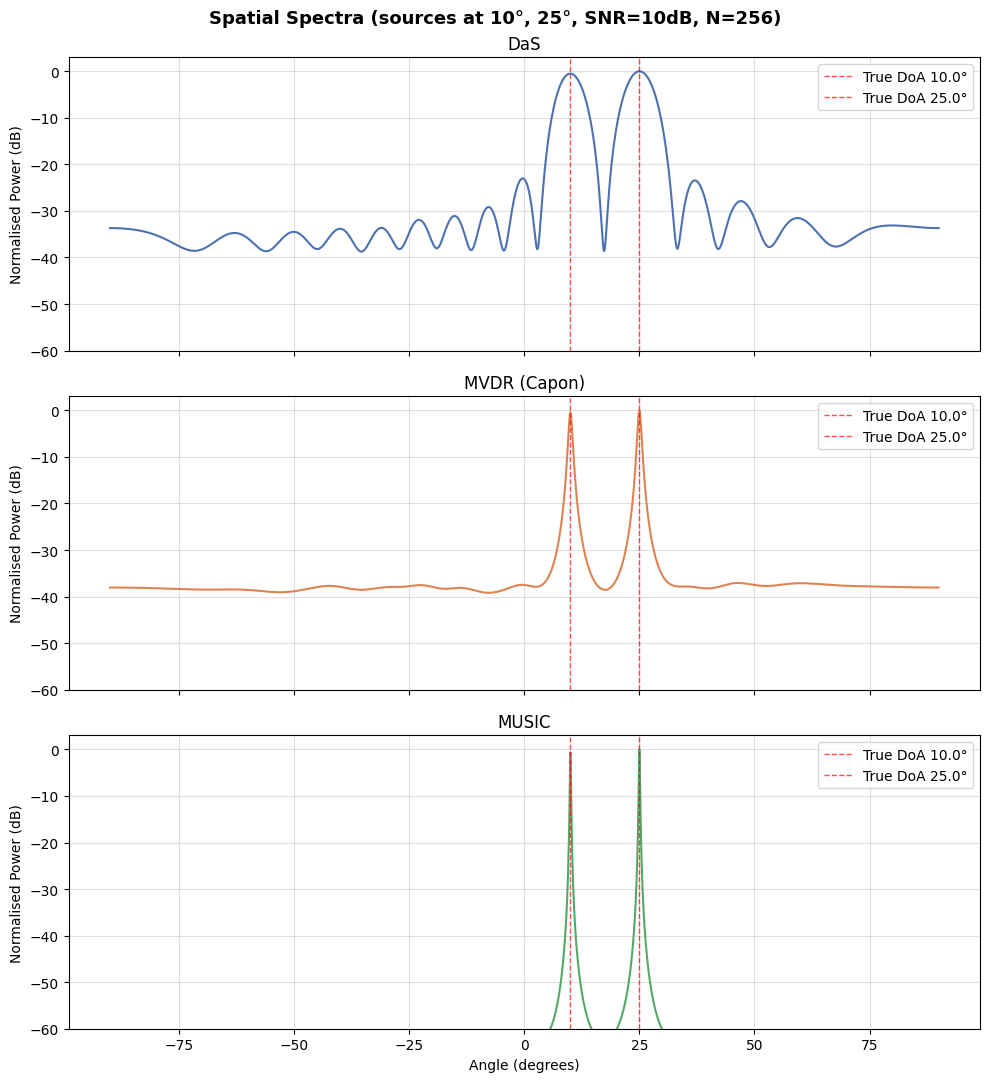

In [6]:
import matplotlib.pyplot as plt

def to_db(s):
    s = s / s.max()
    return 20 * np.log10(s + 1e-12)

true_thetas = [10.0, 25.0]

spec_das   = bf.run_das(R, scan_angles)
spec_mvdr  = bf.run_mvdr(R, scan_angles)
spec_music = bf.run_music(R, scan_angles, num_sources=2)

fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
fig.suptitle("Spatial Spectra (sources at 10°, 25°, SNR=10dB, N=256)", fontsize=13, fontweight="bold")

for ax, spec, label, color in zip(
    axes,
    [spec_das, spec_mvdr, spec_music],
    ["DaS", "MVDR (Capon)", "MUSIC"],
    ["#4C72B0", "#DD8452", "#55A868"]
):
    ax.plot(scan_angles, to_db(spec), color=color, linewidth=1.5)
    for theta in true_thetas:
        ax.axvline(theta, color="red", linestyle="--", linewidth=1, alpha=0.7, label=f"True DoA {theta}°")
    ax.set_ylabel("Normalised Power (dB)")
    ax.set_title(label)
    ax.set_ylim(-60, 3)
    ax.grid(True, alpha=0.4)
    ax.legend()

axes[-1].set_xlabel("Angle (degrees)")
plt.tight_layout()
plt.show()